# Supermarket Sales Analysis

**Project:** Sales performance analysis across supermarket products, categories, branches, customers, and payment methods.

This notebook loads and validates the supplied CSV, recalculates sales from quantity and unit price, summarizes performance, and creates charts. All currency values are reported in Indian rupees (₹).

**Dataset:** [Google Sheets source](https://docs.google.com/spreadsheets/d/1QIX__4VObHFMEXnRM2xJyXmB5JAB2peHrJcQ41_U9TE/edit?usp=sharing). Keep `SUPER MARKET DATA - supermarket_sales_500_rows.csv` beside this notebook. If it is absent, the notebook attempts to read the public CSV export online.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

CSV_NAME = "SUPER MARKET DATA - supermarket_sales_500_rows.csv"
CSV_URL = (
    "https://docs.google.com/spreadsheets/d/"
    "1QIX__4VObHFMEXnRM2xJyXmB5JAB2peHrJcQ41_U9TE/export?format=csv"
)
local_csv = Path.cwd() / CSV_NAME

if local_csv.exists():
    df = pd.read_csv(local_csv)
    print(f"Loaded local dataset: {local_csv}")
else:
    print("Local CSV not found; attempting to load the Google Sheets CSV export.")
    df = pd.read_csv(CSV_URL)

print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
df.head()

Loaded local dataset: C:\Users\HOME\Music\Super Market Analysis\SUPER MARKET DATA - supermarket_sales_500_rows.csv
Rows: 500 | Columns: 13


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.80,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.90,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.40,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.50,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.10,652.85


## 1. Data quality and preparation

Check the expected columns, missing values, duplicate transactions, numeric values, and whether the supplied Sales field agrees with the required calculation. The analysis then uses the recalculated Sales field.

In [2]:
required_columns = {
    "Invoice ID", "Date", "Branch", "City", "Customer Type", "Gender",
    "Product", "Category", "Quantity", "Unit Price", "Payment", "Rating", "Sales"
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

quality_summary = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Data type": df.dtypes.astype(str),
})
print("Data-quality summary:")
display(quality_summary)

duplicate_rows = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_rows}")

for column in ["Quantity", "Unit Price", "Rating", "Sales"]:
    df[column] = pd.to_numeric(df[column], errors="raise")
df["Date"] = pd.to_datetime(df["Date"], errors="raise")

if df[["Quantity", "Unit Price", "Rating", "Sales"]].isna().any().any():
    raise ValueError("Unexpected missing values found in required numeric fields.")
if (df["Quantity"] <= 0).any() or (df["Unit Price"] < 0).any():
    raise ValueError("Quantity must be positive and Unit Price cannot be negative.")
if not df["Rating"].between(0, 5).all():
    raise ValueError("Customer ratings must be between 0 and 5.")

df["Calculated Sales"] = df["Quantity"] * df["Unit Price"]
sales_match = (df["Calculated Sales"] - df["Sales"]).abs() < 0.005
print(f"Sales calculation matches source to within ₹0.005: {sales_match.all()}")
if not sales_match.all():
    display(df.loc[~sales_match, ["Invoice ID", "Quantity", "Unit Price", "Sales", "Calculated Sales"]])
df["Sales"] = df["Calculated Sales"]

print(f"Date range: {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
print(f"Total sales: ₹{df['Sales'].sum():,.2f}")

Data-quality summary:


,Missing values,Data type
Invoice ID,0,str
Date,0,str
Branch,0,str
City,0,str
Customer Type,0,str
Gender,0,str
Product,0,str
Category,0,str
Quantity,0,int64
Unit Price,0,float64


Duplicate rows: 0


Sales calculation matches source to within ₹0.005: True
Date range: 2026-01-01 to 2026-07-01
Total sales: ₹244,411.08


## 2. Key metrics and grouped summaries

Sales totals measure monetary performance. Transaction counts are used for payment popularity; units sold are shown separately so these measures are not confused.

In [3]:
total_sales = df["Sales"].sum()
average_rating = df["Rating"].mean()
sales_per_transaction = df["Sales"].mean()

product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
category_summary = (
    df.groupby("Category")
    .agg(Transactions=("Invoice ID", "count"), Units=("Quantity", "sum"), Sales=("Sales", "sum"))
    .sort_values("Sales", ascending=False)
)
branch_sales = (
    df.groupby(["Branch", "City"])["Sales"].sum().sort_values(ascending=False)
)
payment_counts = df["Payment"].value_counts()
customer_summary = df.groupby("Customer Type")["Sales"].agg(
    Transactions="count", Average_Sales="mean", Total_Sales="sum"
)

print(f"Transactions: {len(df):,}")
print(f"Total sales: ₹{total_sales:,.2f}")
print(f"Average transaction sales: ₹{sales_per_transaction:,.2f}")
print(f"Average customer rating: {average_rating:.2f} / 5")
print(f"Highest-sales product: {product_sales.index[0]} (₹{product_sales.iloc[0]:,.2f})")
print(f"Highest-sales category: {category_summary.index[0]} (₹{category_summary.iloc[0]['Sales']:,.2f})")
best_branch = branch_sales.index[0]
print(f"Highest-sales branch: Branch {best_branch[0]} ({best_branch[1]}) (₹{branch_sales.iloc[0]:,.2f})")
print(f"Most-used payment method: {payment_counts.index[0]} ({payment_counts.iloc[0]} transactions)")

display(category_summary)
display(branch_sales.rename("Sales").to_frame())
display(payment_counts.rename("Transactions").to_frame())
display(customer_summary)

Transactions: 500
Total sales: ₹244,411.08
Average transaction sales: ₹488.82
Average customer rating: 3.99 / 5
Highest-sales product: Cheese (₹27,906.30)
Highest-sales category: Beverages (₹56,108.24)
Highest-sales branch: Branch C (Mumbai) (₹72,469.45)
Most-used payment method: UPI (127 transactions)


,Transactions,Units,Sales
Category,,,
Beverages,82,465,"56,108.24"
Personal Care,73,399,"45,943.96"
Dairy,68,345,"43,992.00"
Grocery,82,439,"40,470.47"
Fruits,44,223,"23,263.17"
Snacks,75,443,"16,992.97"
Vegetables,48,290,"11,124.17"
Bakery,28,164,"6,516.10"


,,Sales
Branch,City,
C,Mumbai,"72,469.45"
B,Delhi,"64,116.26"
D,Bengaluru,"55,468.29"
A,Jaipur,"52,357.08"


,Transactions
Payment,
UPI,127
Net Banking,126
Card,125
Cash,122


,Transactions,Average_Sales,Total_Sales
Customer Type,,,
Member,296,483.14,"143,009.30"
Normal,204,497.07,"101,401.78"


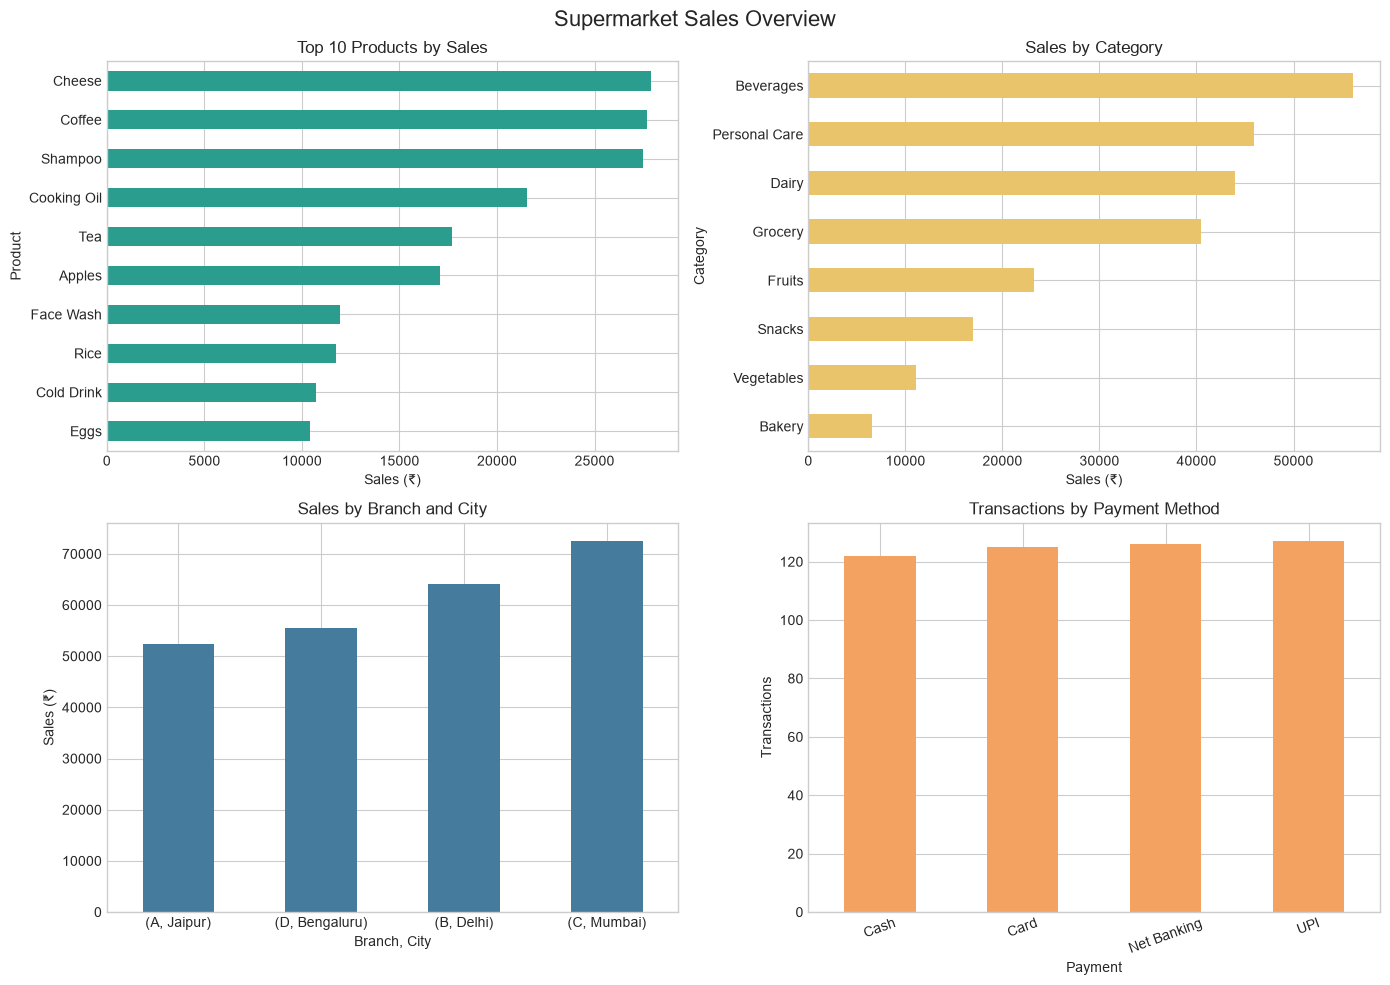

In [4]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

product_sales.head(10).sort_values().plot(kind="barh", ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Top 10 Products by Sales")
axes[0, 0].set_xlabel("Sales (₹)")

category_summary["Sales"].sort_values().plot(kind="barh", ax=axes[0, 1], color="#e9c46a")
axes[0, 1].set_title("Sales by Category")
axes[0, 1].set_xlabel("Sales (₹)")

branch_sales.sort_values().plot(kind="bar", ax=axes[1, 0], color="#457b9d")
axes[1, 0].set_title("Sales by Branch and City")
axes[1, 0].set_xlabel("Branch, City")
axes[1, 0].set_ylabel("Sales (₹)")
axes[1, 0].tick_params(axis="x", rotation=0)

payment_counts.sort_values().plot(kind="bar", ax=axes[1, 1], color="#f4a261")
axes[1, 1].set_title("Transactions by Payment Method")
axes[1, 1].set_ylabel("Transactions")
axes[1, 1].tick_params(axis="x", rotation=20)

fig.suptitle("Supermarket Sales Overview", fontsize=16)
fig.tight_layout()
plt.show()

## 3. Interpretation and business recommendations

- Cheese has the largest product sales total (₹27,906.30); monitor its stock availability and margin before increasing orders.
- Branch C in Mumbai leads branch sales (₹72,469.45). Compare its product mix, operating hours, footfall, and local promotions with other branches before attributing the difference to a cause.
- Beverages leads category sales (₹56,108.24). Use replenishment planning to reduce stockouts while tracking spoilage and gross margin.
- UPI is the most-used payment method (127 transactions), although it is close to Net Banking (126), Card (125), and Cash (122). Maintain multiple payment options.
- Normal customers have a higher average transaction value (₹497.07) than Members (₹483.14) in this sample. Test targeted member offers and compare outcomes; these descriptive averages do not show that membership causes lower spending.
- The mean rating is 3.99/5. Review low-rating feedback and track ratings alongside service changes.

## Conclusion and limitations

The 500 supplied transactions show ₹244,411.08 in sales, with no missing values or exact duplicate rows and source sales matching the quantity-times-price calculation. Results describe only the supplied dataset and period; they do not establish causality, profitability, stock availability, or customer lifetime value. Validate recommendations against margin, inventory, and longer-term data before making operational changes.